# Hands-On Guide – Bayesian Logistic‐Regression Class  
*A cookbook-style walkthrough using the `LogisticRegression`, `Grid2D` and
`GridApproximation2D` helpers from the notebook.*

---

## 0. Prerequisites

```python
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
```


## 🔍 1. What is the purpose of the model? What type of problem does it solve?

**Purpose**:  
Bayesian logistic regression is used to model the probability of binary (or count-based) outcomes as a function of one or more continuous inputs, while **quantifying uncertainty** over model parameters.

**Problem type**:
- **Supervised classification** (in this case: binary classification or count prediction)
- Each observation is a number of "successes" (e.g., O-ring failures) out of a known number of trials (e.g., 6)
- You want to **predict probabilities**, not just labels, and understand how confident you are

---

## 🧮 2. How is the prior and likelihood of the model defined?

**Likelihood**:  
Each data point is modeled as:

$$
y_i \sim \text{Binomial}(N, \theta_i), \quad \text{where } \theta_i = \sigma(\alpha + \beta x_i)
$$

- $x_i$: observed input (e.g., temperature)  
- $y_i$: observed number of failures  
- $N$: total number of trials (e.g., 6)  
- $\sigma(z) = \frac{1}{1 + e^{-z}}$: sigmoid function  
- $\alpha, \beta$: unknown parameters  

So the full likelihood is:

$$
p(y \mid \alpha, \beta) = \prod_{i=1}^n \text{Binomial}(y_i \mid N, \theta_i)
$$

**Prior**:  
We place **independent Gaussian priors** on the parameters:

$$
\alpha \sim \mathcal{N}(0, 1), \quad \beta \sim \mathcal{N}(0, 1)
$$

So:

$$
p(\alpha, \beta) = \mathcal{N}(\alpha \mid 0, 1) \cdot \mathcal{N}(\beta \mid 0, 1)
$$

---

## 📦 3. How is the posterior distribution computed/approximated?

We use **grid approximation**.

**Steps**:

1. Define a grid over parameter values:  
   $\alpha \in \{a_1, \dots, a_K\}$, $\beta \in \{b_1, \dots, b_L\}$

2. Compute the **log-joint** at each grid point:

$$
\log p(y, \alpha, \beta) = \log p(y \mid \alpha, \beta) + \log p(\alpha, \beta)
$$

3. Shift log-joint values to avoid underflow:

$$
\tilde{\pi}_{ij} = \exp\left( \log p(y, a_i, b_j) - \max_{i,j} \log p(y, a_i, b_j) \right)
$$

4. Normalize to get posterior:

$$
q(a_i, b_j) = \frac{\tilde{\pi}_{ij}}{Z}, \quad Z = \sum_{i,j} \tilde{\pi}_{ij}
$$

This gives a **discrete posterior** $q(\alpha, \beta)$ defined on the grid.

---

## 🔮 4. How is the posterior predictive distribution computed/approximated?

The full Bayesian posterior predictive distribution is:

$$
p(y^* = k \mid x^*, D) = \sum_{\alpha, \beta} p(y^* = k \mid x^*, \alpha, \beta) \cdot q(\alpha, \beta)
$$

For each term in the sum:

- Compute:

$$
\theta^* = \sigma(\alpha + \beta x^*)
$$

- Compute binomial probability:

$$
p(y^* = k \mid \theta^*) = \binom{N}{k} (\theta^*)^k (1 - \theta^*)^{N - k}
$$

- Multiply by posterior weight $q(\alpha, \beta)$ and sum over grid.

This gives:

- **Predictive mean**:  
  $\mathbb{E}[y^*] = \sum_k k \cdot p(y^* = k)$

- **Predictive variance**
  $\text{Var}(y^*) = \sum_k (k - \mathbb{E}[y^*])^2 \cdot p(y^* = k)$

- **Uncertainty-aware prediction**
  $p(y^* \mid x^*)$ captures uncertainty in parameters

---

## 🔢 5. How do you make a prediction given the model?

There are two common strategies:

### a) Plugin Prediction (MAP):
1. Find most likely parameter values:

$$
(\alpha^*, \beta^*) = \arg\max_{\alpha, \beta} q(\alpha, \beta)
$$

2. Then predict:

$$
\theta^* = \sigma(\alpha^* + \beta^* x^*)
$$

$$
y^* \sim \text{Binomial}(N, \theta^*)
$$

3. **Mean prediction**:

$$
\mathbb{E}[y^*] = N \cdot \theta^*
$$

---

### b) Full Bayesian Prediction:

Average over all parameter values:

$$
p(y^* \mid x^*) = \sum_{\alpha, \beta} p(y^* \mid \alpha, \beta, x^*) \cdot q(\alpha, \beta)
$$

This gives:
- More stable and reliable predictions
- Incorporates parameter uncertainty

---

## 🧵 TL;DR Summary (Story Form)

- We're modeling a **count of binary events** using logistic regression, but we want to do it the **Bayesian way**.
- We define a **grid of possible parameter values**, compute the **posterior distribution** over them using the **likelihood and priors**, and then either **plug in the best values** or **average over all possibilities** to make predictions that reflect our uncertainty.


In [3]:
%matplotlib inline
import pylab as plt
import pandas as pd
import jax.numpy as jnp
from jax import random
import seaborn as snb


from scipy.stats import binom as binom_dist


snb.set_style('darkgrid')
snb.set_theme(font_scale=1.)
colors = 'brgmc'
import sys
sys.path.insert(0, "../") 
from TOOL_BOX_OF_FUNCTIONS.LOGISTIC_REGRESSION_WEEK_2 import LOGISTIC_REG_WEEK_2 as LR

# 1. Load or create data

Below we fabricate a toy data-set that mimics the O-ring scenario
(6 trials per launch, failures more likely at low temperature),
but any 1-D feature + binomial count will work.

In [4]:
key = random.PRNGKey(0)

M        = 25                      # number of launches
N_i      = 6                       # always six O-rings
temp_C   = random.uniform(key, (M,), minval=-10, maxval=30)  # °C
true_a   = -1.3                    # α  (intercept)
true_b   = -0.18                   # β  (slope, ↓ prob with ↑ temp)
true_p   = 1. / (1. + jnp.exp(-(true_a + true_b * temp_C)))
y_counts = random.binomial(key, N_i, true_p)                 # failures


# compute mean and standard deviation of temperatures
tmean, tstd = jnp.mean(temp_C), jnp.std(temp_C)

# standardize temperatures
standardize = lambda t_: (t_ - tmean)/tstd
x = standardize(temp_C)

#  2. Instantiate the model

In [5]:
model = LR.LogisticRegression(x=x,
                           y=y_counts,
                           N=N_i,        # scalar works fine
                           sigma2_alpha=2.0,
                           sigma2_beta =3.0)


# 3. Explore the surface – likelihood, prior, posterior

Choose a grid that covers the plausible range of parameters.
Here: α,β ∈ [-4,4].

In [6]:
alphas = jnp.linspace(-4, 4, 100)   # 100×120 ≈ 1e4 evals – instant in JAX
betas  = jnp.linspace(-4, 4, 120)

like_grid  = LR.Grid2D(alphas, betas, model.log_likelihood, 'Likelihood')
prior_grid = LR.Grid2D(alphas, betas, model.log_prior,      'Prior')
post_grid  = LR.Grid2D(alphas, betas, model.log_joint,      'Posterior')


True


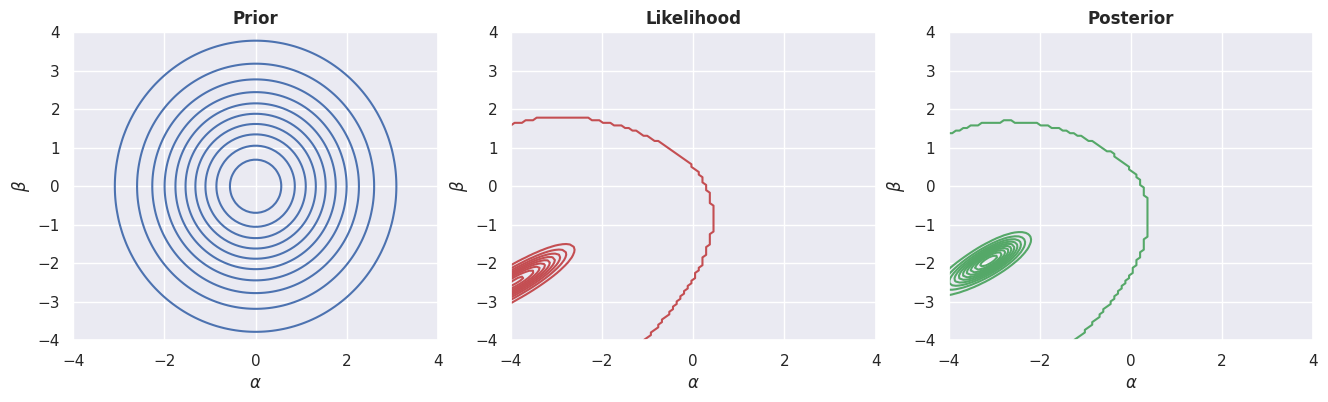

In [5]:
fig, ax = plt.subplots(1,3,figsize=(16,4))
for g, col in zip([prior_grid, like_grid, post_grid], 'brg'):
    g.plot_contours(ax[['Prior','Likelihood','Posterior'].index(g.name)],
                    f=jnp.exp, color=col)


# 

# 4. Point estimates

In [6]:
alpha_MLE, beta_MLE = like_grid.argmax     # Maximum-Likelihood
alpha_MAP, beta_MAP = post_grid.argmax     # Maximum-A-Posteriori
print('MLE =', (alpha_MLE, beta_MLE))
print('MAP =', (alpha_MAP, beta_MAP))


MLE = (Array(-3.8383837, dtype=float32), Array(-2.4537816, dtype=float32))
MAP = (Array(-3.1111112, dtype=float32), Array(-1.9159662, dtype=float32))



# 4. Point estimates

Use them in a plugin predictor:

$$\hat{\theta}(x)=\sigma(\hat{\alpha}+\hat{\beta}x),\quad y \sim \text{Binomial}(N,\hat{\theta})$$

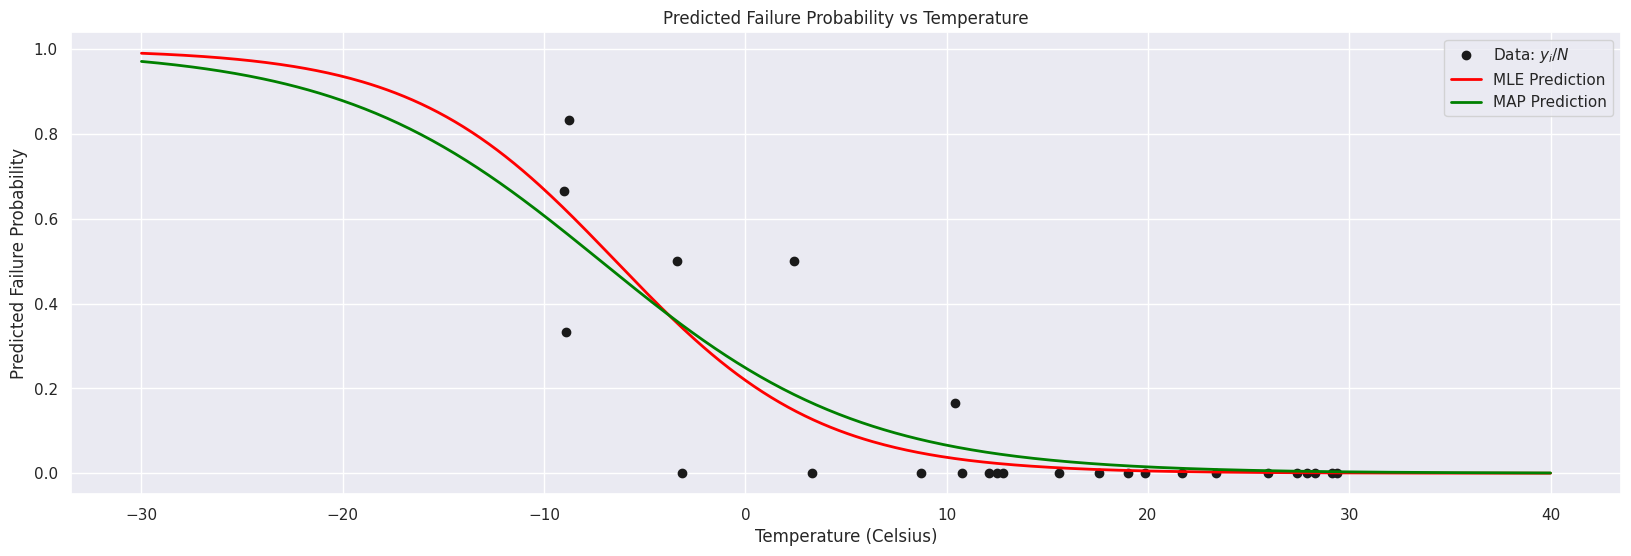

In [7]:

def plot_data(ax=None, counts=True):
    if counts:
        ax.plot(temp_C, y_counts, 'mo', label='Data: $y_i$')
        ax.set(ylabel='Number of failed o-rings')
    else:
        ax.plot(temp_C, y_counts/N_i, 'ko', label='Data: $y_i/N$')
        ax.set(ylabel='Fraction of failed o-rings')
    ax.set(xlabel='Temperature (celcius)')
    ax.legend(loc='lower left')

def plugin_prob(x_star, alpha, beta):
    p = model.theta(x_star, alpha, beta)
    return p                        # scalar in (0,1)


temp_pred = jnp.linspace(-30, 40, 500)
x_pred = standardize(temp_pred)
N_pred = 6

MLE_pred = plugin_prob(x_star=x_pred, alpha=alpha_MLE, beta=beta_MLE)
MAP_pred = plugin_prob(x_star=x_pred, alpha=alpha_MAP, beta=beta_MAP)


# plot the predictions

fig, ax = plt.subplots(1, 1, figsize=(20, 6))
# Plot the data
plot_data(ax, counts=False)

# Plot MLE predictions
ax.plot(temp_pred, MLE_pred, color='red', label='MLE Prediction', linewidth=2)
# Plot MAP predictions
ax.plot(temp_pred, MAP_pred, color='green', label='MAP Prediction', linewidth=2)
# Add labels and legend
ax.set_xlabel('Temperature (Celsius)')
ax.set_ylabel('Predicted Failure Probability')
ax.set_title('Predicted Failure Probability vs Temperature')
ax.legend()
plt.show()  

# 5. (Recommended) Grid-posterior approximation

In [14]:
post_approx = LR.GridApproximation2D(alphas, betas, model.log_joint, name='Posterior Approx')


In [18]:
post_approx.log_joint_grid

Array([[ -19.522202,  -18.122246,  -16.761223, ..., -190.75534 ,
        -194.79688 , -198.89835 ],
       [ -20.496708,  -19.061504,  -17.663887, ..., -191.5567  ,
        -195.66272 , -199.82748 ],
       [ -21.519085,  -20.049454,  -18.616108, ..., -192.44312 ,
        -196.61273 , -200.83987 ],
       ...,
       [-429.7446  , -429.04388 , -428.37897 , ..., -657.8287  ,
        -662.77216 , -667.7455  ],
       [-437.9692  , -437.28207 , -436.69858 , ..., -666.0948  ,
        -670.99066 , -675.93616 ],
       [-446.25266 , -445.64435 , -445.1034  , ..., -674.4014  ,
        -679.26807 , -684.1789  ]], dtype=float32)

In [9]:
E_alpha = post_approx.compute_expectation(lambda a,b: a)
Var_a   = post_approx.compute_expectation(lambda a,b: (a-E_alpha)**2)
print(f'Posterior   E[α]={E_alpha:.2f}, SD={jnp.sqrt(Var_a):.2f}')

Posterior   E[α]=-3.15, SD=0.43


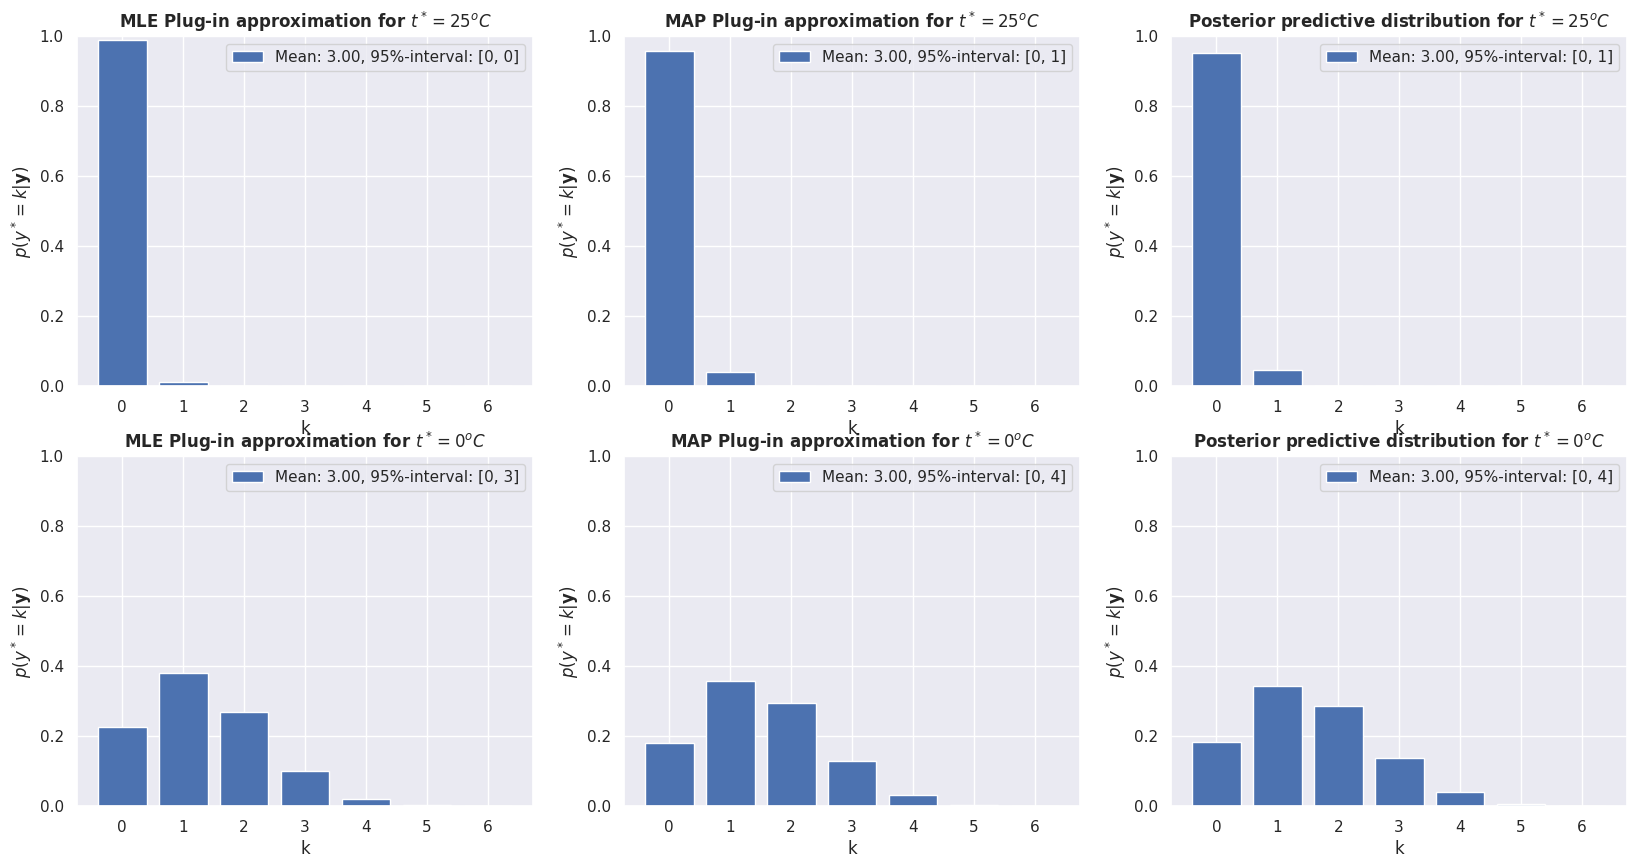

In [10]:
# target temperatures t^*
temp_stars = [25, 0]

# outcome space for y^*
ks = jnp.arange(0, 6+1)

# predictive likelihood p(y^*=k|x^*, alpha, beta)
pred_lik = lambda k, x_star, alpha, beta: binom_dist.pmf(k=k, n=6, p=model.theta(x_star, alpha, beta))

# prep figure
fig, ax = plt.subplots(2, 3, figsize=(20, 10))

mean_and_interval_label = lambda dist: f'Mean: {dist.mean:3.2f}, 95%-interval: [{dist.central_interval()[0]:d}, {dist.central_interval()[1]:d}]'

for n, t_star in enumerate(temp_stars):

    # standardize to get x^*
    x_star = standardize(t_star)

    # compute plugin approximations using MLE and MAP. Shape must be [7] (matching the shape of ks)
    pred_lik_probs_MLE = pred_lik(ks, x_star, alpha_MLE, beta_MLE)
    pred_lik_probs_MAP = pred_lik(ks, x_star, alpha_MAP, beta_MAP)
    
    # compute posterior predictive distribution as a weighted averaged over all parameter vales. Shape must be [7] (matching the shape of ks)
    pred_lik_bayes_probs = jnp.sum(pred_lik(ks, x_star, post_approx.alphas_flat[:, None], post_approx.betas_flat[:, None])*post_approx.probabilities_flat[:, None], axis=0) 

    # prepare for plotting etc
    pred_dist_MLE = LR.DiscreteDistribution1D(ks, pred_lik_probs_MLE, name='MLE Plug-in approximation')
    pred_dist_MAP = LR.DiscreteDistribution1D(ks, pred_lik_probs_MAP, name='MAP Plug-in approximation')
    pred_dist_bayes = LR.DiscreteDistribution1D(ks, pred_lik_bayes_probs, name="Posterior predictive distribution")

    # plot
    for i, dist in enumerate([pred_dist_MLE, pred_dist_MAP, pred_dist_bayes]):
        ax[n, i].bar(ks, dist.probabilities, label=mean_and_interval_label(dist))
        ax[n, i].set(xlabel='k', ylabel='$p(y^* = k|\\mathbf{y})$', ylim =(0, 1))
        ax[n, i].set_ylim((0, 1))
        ax[n, i].set_title(f'{dist.name} for $t^* = {t_star}^oC$', fontweight='bold')
        ax[n, i].set(xlabel='k', ylabel='$p(y^* = k|\\mathbf{y})$', ylim =(0, 1))
        ax[n, i].legend()


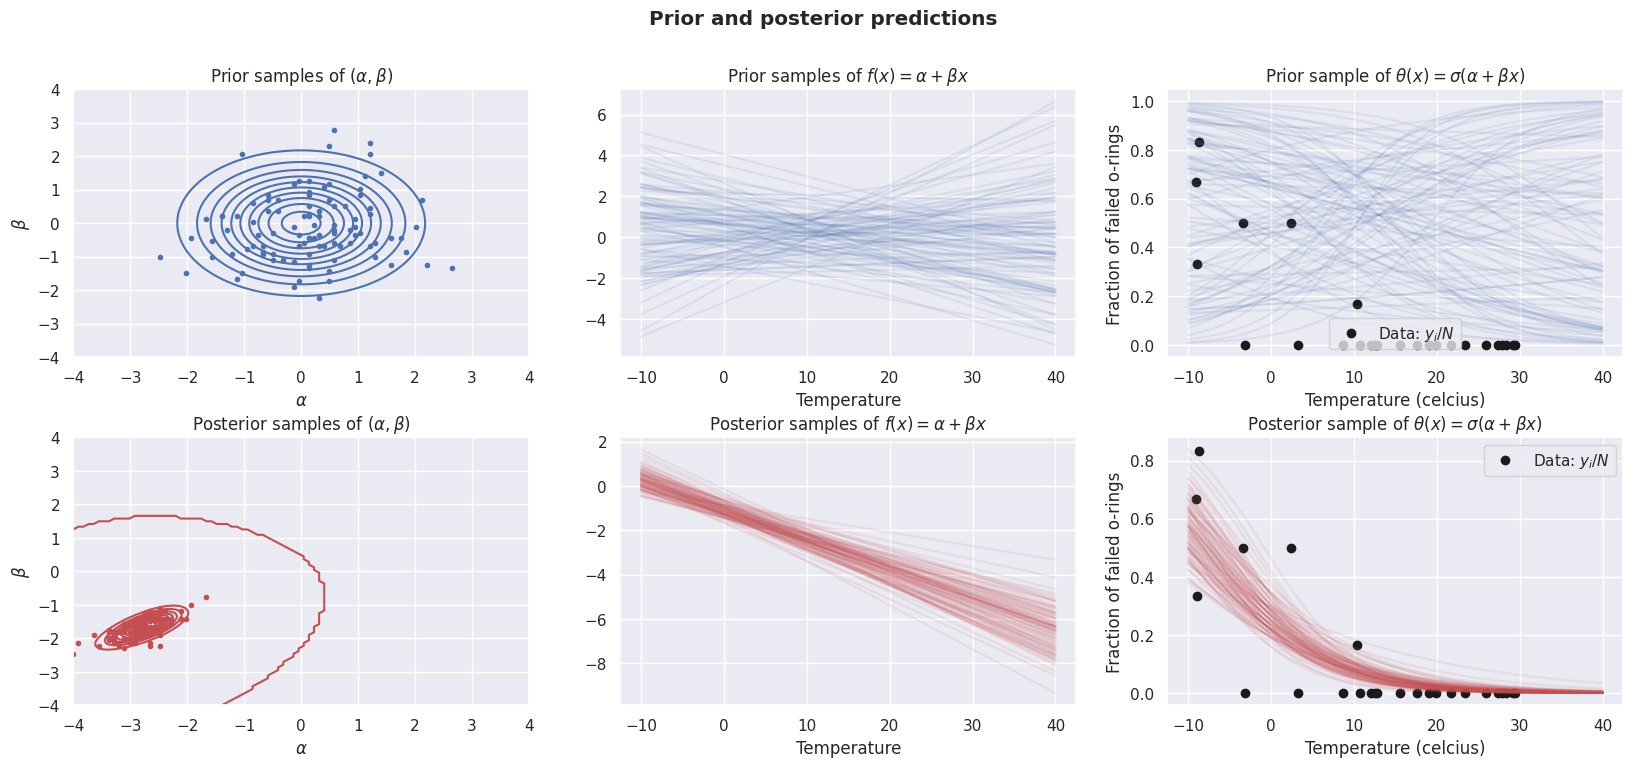

In [11]:
# data for predictions
temp_pred = jnp.linspace(-10, 40, 500)
x_pred = standardize(temp_pred)
N_pred = 6

# number of samples plot
num_samples = 100

# grid
num_alpha, num_beta = 90, 100
alphas = jnp.linspace(-4, 4, num_alpha)
betas = jnp.linspace(-4, 4, num_beta)

# set up prior and posterior for visualization purposes
model = LR.LogisticRegression(x, y_counts, N_i, sigma2_alpha=1., sigma2_beta=1.)
post_approx = LR.GridApproximation2D(alphas, betas, model.log_joint, name='Posterior')
prior_approx = LR.GridApproximation2D(alphas, betas, model.log_prior, name='Prior')

# specify seed
seed = 123
key = random.PRNGKey(seed)


# plot for each distribution...
fig, ax = plt.subplots(2, 3, figsize=(20, 8))
for idx_plot, dist in enumerate([prior_approx, post_approx]):
    key, subkey = random.split(key)

    # plot data and contours of distribution
    plot_data(ax[idx_plot, 2], counts=False)
    dist.plot_contours(ax[idx_plot, 0], f=jnp.exp, color=colors[idx_plot])

    # get (alpha, beta)-samples to visualize
    alpha_samples, beta_samples = dist.sample(subkey, num_samples)

    # compute samples of f(x_pred) and theta(x_pred). Shape must be [num_samples, len(temp_pred)] for both f_samples and theta_samples
    f_samples = model.f(x_pred, alpha_samples, beta_samples) 
    theta_samples = model.theta(x_pred, alpha_samples, beta_samples) 

    # plot
    ax[idx_plot, 0].plot(alpha_samples, beta_samples, '.', color=colors[idx_plot])

    # plot each sample of f and theta
    ax[idx_plot, 1].plot(temp_pred, f_samples.T, '', color=colors[idx_plot], alpha=0.1)
    ax[idx_plot, 2].plot(temp_pred, theta_samples.T, '', color=colors[idx_plot], alpha=0.1)
    ax[idx_plot, 2].legend()

    # title and labels
    ax[idx_plot, 0].set(title=f'{dist.name} samples of $(\\alpha, \\beta)$')
    ax[idx_plot, 1].set(title=f'{dist.name} samples of $f(x) = \\alpha + \\beta x$', xlabel='Temperature')
    ax[idx_plot, 2].set(title=f'{dist.name} sample of $\\theta(x) = \\sigma(\\alpha + \\beta x)$')

fig.suptitle('Prior and posterior predictions', fontweight='bold')
fig.subplots_adjust(hspace=0.3)


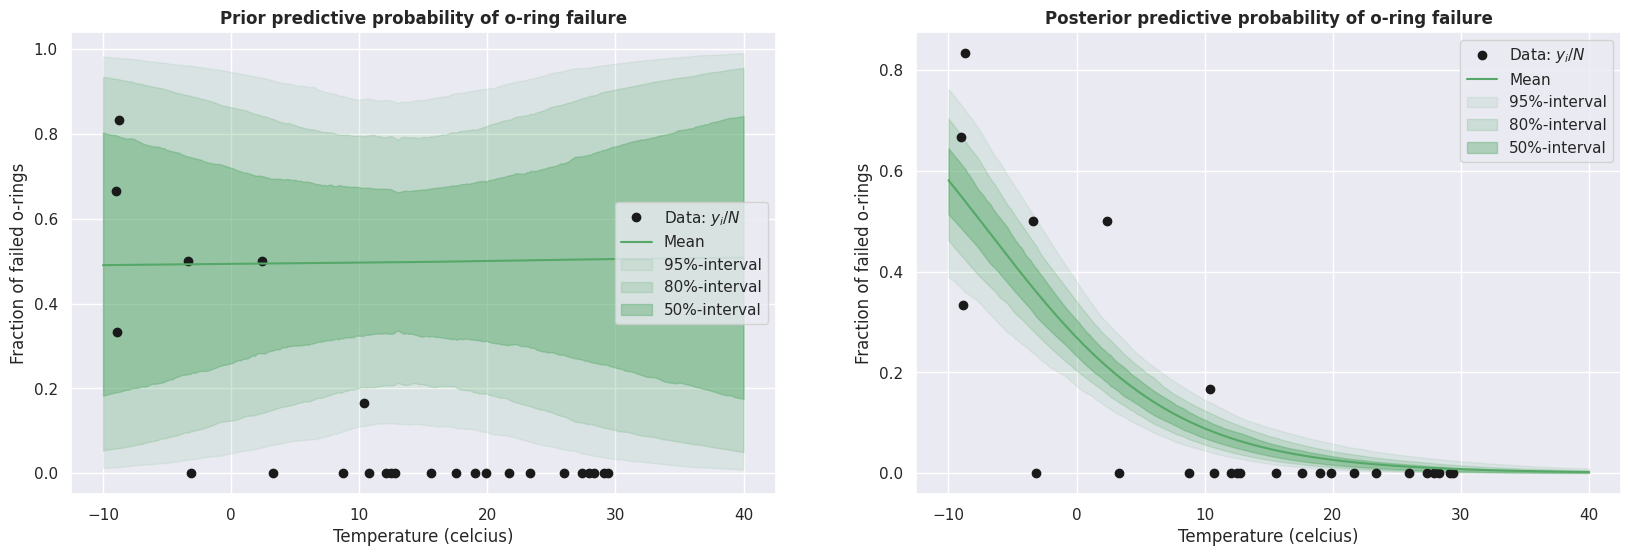

In [12]:
# set seed
seed = 0
key = random.PRNGKey(seed)

# set up prior and posterior for visualization purposes
model = LR.LogisticRegression(x, y_counts, N_i, sigma2_alpha=1., sigma2_beta=1.)
post_approx = LR.GridApproximation2D(alphas, betas, model.log_joint, name='Posterior')
prior_approx = LR.GridApproximation2D(alphas, betas, model.log_prior, name='Prior')

# plot
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
plot_data(ax[0], counts=False)
plot_data(ax[1], counts=False)

num_samples = 2000

for idx_plot, dist in enumerate([prior_approx, post_approx]):
    key, subkey = random.split(key)

    alpha_samples, beta_samples = dist.sample(subkey, num_samples)

    theta_samples = model.theta(x_pred, alpha_samples, beta_samples)
    theta_mean = theta_samples.mean(0)
    theta_lower = jnp.quantile(theta_samples, 0.025, axis=0)
    theta_upper = jnp.quantile(theta_samples, 1-0.025,)

    ax[idx_plot].plot(temp_pred, theta_mean, 'g-', label='Mean')
    for interval_size, b in [(0.95, 0.1), (0.8, 0.2), (0.5, 0.4)]:
        c = 1-interval_size
        theta_lower = jnp.quantile(theta_samples, c/2, axis=0)
        theta_upper = jnp.quantile(theta_samples, 1-c/2, axis=0)
        ax[idx_plot].fill_between(temp_pred, theta_lower, theta_upper, color='g', alpha=b, label=f'{interval_size*100:2.0f}%-interval')
    ax[idx_plot].legend()
    ax[idx_plot].set_title(f'{dist.name} predictive probability of o-ring failure', fontweight='bold')

Text(0.5, 1.0, 'Posterior predictive probability of at least one o-ring failure')

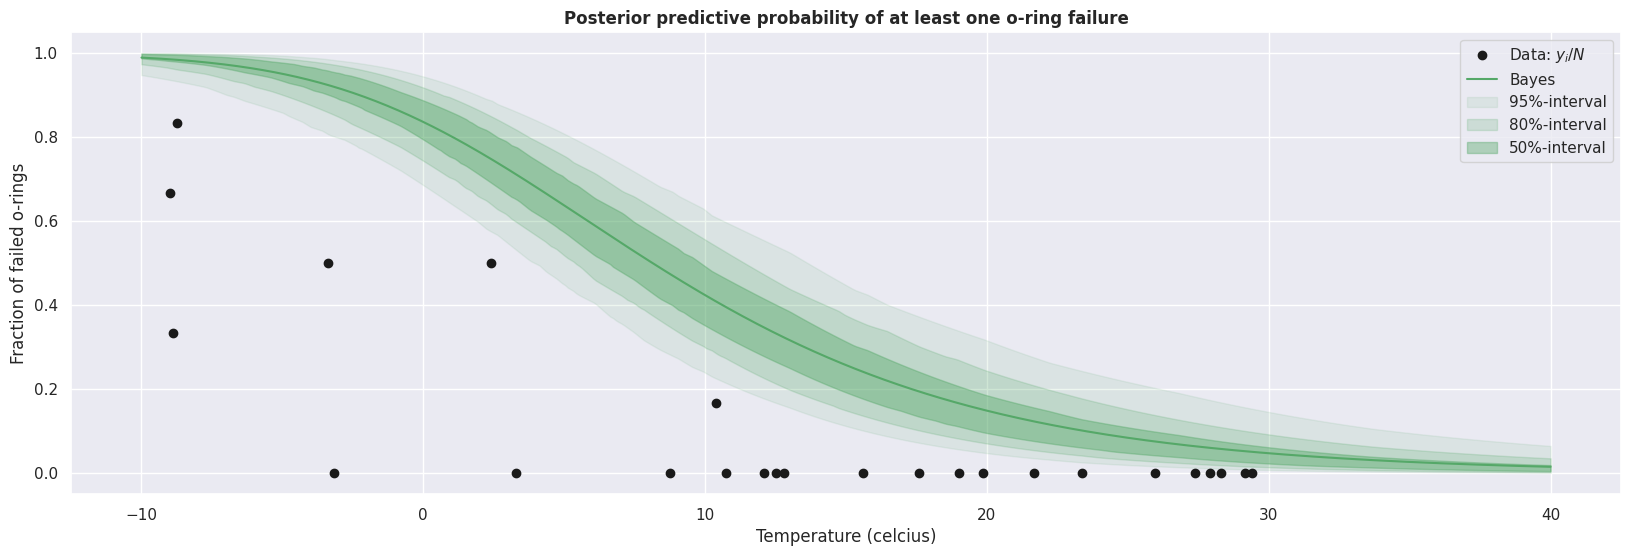

In [14]:
# set seed and number of samples
seed = 0
key = random.PRNGKey(seed)
num_samples = 2000


# set up prior and posterior for visualization purposes
model = LR.LogisticRegression(x, y_counts, N_i, sigma2_alpha=1., sigma2_beta=1.)
post_approx = LR.GridApproximation2D(alphas, betas, model.log_joint, name='Posterior')

alpha_samples, beta_samples = post_approx.sample(key, num_samples)
theta_samples = model.theta(x_pred, alpha_samples, beta_samples)

# probability of at least one failure wrt. a binomial post_approxrinution
prob_at_least_one_failure = 1 - (1-theta_samples)**N_pred

# compute mean and interval
post_mean = prob_at_least_one_failure.mean(0)
post_lower = jnp.quantile(prob_at_least_one_failure, 0.025, axis=0)
post_upper = jnp.quantile(prob_at_least_one_failure, 1-0.025,)

# plot
fig, ax = plt.subplots(1, 1, figsize=(20, 6))
plot_data(ax, counts=False)

ax.plot(temp_pred, post_mean, 'g-', label='Bayes')
for interval_size, b in [(0.95, 0.1), (0.8, 0.2), (0.5, 0.4)]:
    c = 1-interval_size
    post_lower = jnp.quantile(prob_at_least_one_failure, c/2, axis=0)
    post_upper = jnp.quantile(prob_at_least_one_failure, 1-c/2, axis=0)
    ax.fill_between(temp_pred, post_lower, post_upper, color='g', alpha=b, label=f'{interval_size*100:2.0f}%-interval')
ax.legend()
ax.set_title(f'{post_approx.name} predictive probability of at least one o-ring failure', fontweight='bold')

✅ Overview: What Summaries Can We Extract from Grid Approximation?

Once you have a grid approximation of the posterior over parameters (like in your `GridApproximation2D`), you can extract:

| Summary                      | Description                                         | How to compute it                                                                                                  |
| ---------------------------- | --------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------ |
| **Posterior**                | Full joint posterior $p(\alpha, \beta \mid D)$      | `grid_approx.probabilities_grid` — shape (n\_alpha, n\_beta)                                                       |
| **Prior**                    | Prior distribution over α and β                     | Not directly stored — use `model.log_prior(alpha, beta)` over the same grid                                        |
| **Log-Joint**                | Unnormalized posterior (log-likelihood + log-prior) | `grid_approx.log_joint_grid`                                                                                       |
| **Posterior Mean**           | $\mathbb{E}[\alpha], \mathbb{E}[\beta]$             | `grid_approx.compute_expectation(lambda a, b: a)` and `...b`                                                       |
| **Posterior Variance**       | $\text{Var}[\alpha], \text{Var}[\beta]$             | Use same function: `grid_approx.compute_expectation(lambda a, b: (a - mean_alpha)**2)`                             |
| **Posterior MAP**            | $\arg\max_{\alpha,\beta} p(\alpha, \beta \mid D)$   | `grid_approx.argmax` (returns α\*, β\*)                                                                            |
| **Marginals**                | $p(\alpha \mid D), p(\beta \mid D)$                 | `grid_approx.pi_alpha`, `grid_approx.pi_beta`                                                                      |
| **Marginal Mean / Variance** | Mean and variance of α or β marginally              | Use `DiscreteDistribution1D(outcomes=alphas, probs=pi_alpha)` and call `.mean`, `.variance`, `.central_interval()` |
| **Credible Interval (CI)**   | 95% central credible interval                       | From `DiscreteDistribution1D(...).central_interval(interval_size=95)`                                              |
| **Posterior Predictive**     | $p(y^* \mid x^*, D)$                                | Use `theta(x*, α, β)` and average over posterior weights                                                           |


# 🛠️ How to Do Each Summary — Code Examples

Let’s suppose you have:

In [24]:
model = LR.LogisticRegression(x, y_counts, N_i)
grid_approx = LR.GridApproximation2D(alphas, betas, model.log_joint)


## 📌 1. Posterior MAP (Maximum a Posteriori)

The **Maximum a Posteriori (MAP)** estimate refers to the mode (i.e., most probable point) of the **posterior distribution** over the parameters.

We want to find the parameters (\alpha_{\text{MAP}}, \beta_{\text{MAP}})\) that **maximize the posterior**:

$$
(\alpha_{\text{MAP}}, \beta_{\text{MAP}}) = \arg\max_{\alpha, \beta} \, p(\alpha, \beta \mid \mathcal{D})
$$

Using **Bayes’ rule**:

$$
p(\alpha, \beta \mid \mathcal{D}) \propto p(\mathcal{D} \mid \alpha, \beta) \cdot p(\alpha, \beta)
$$

Taking the **log** (which preserves the location of the maximum):

$$
(\alpha_{\text{MAP}}, \beta_{\text{MAP}}) = \arg\max_{\alpha, \beta} \, \left[ \log p(\mathcal{D} \mid \alpha, \beta) + \log p(\alpha, \beta) \right]
$$

### 🔹 Components:

- **Likelihood**:
  $$
  \log p(\mathcal{D} \mid \alpha, \beta) = \sum_{i=1}^{n} \log \text{Binomial}(y_i \mid N, \sigma(\alpha + \beta x_i))
  $$

- **Prior** (assuming independent standard normal priors):
  $$
  \log p(\alpha, \beta) = -\frac{1}{2}(\alpha^2 + \beta^2) + \text{const}
  $$

---

So, in practice, we compute this over a **discretized grid** of $(\alpha, \beta)$ values and select the **maximum**:

```python
alpha_map, beta_map = grid_approx.argmax
```

This corresponds to:

> The grid point \((\alpha, \beta)\) that maximizes the **log-joint**  
> $$\log p(\mathcal{D}, \alpha, \beta) = \log p(\mathcal{D} \mid \alpha, \beta) + \log p(\alpha, \beta)$$


## 📌 2. Posterior Mean

We compute the expected value of α and β under the joint posterior approximation:

$$\mathbb{E}[\alpha] = \sum_{i,j }  \alpha_i \cdot \pi_{ij}$$

$$\mathbb{E}[\beta] = \sum_{i,j }  \beta_j \cdot \pi_{ij}$$

Where:
- $\pi_{ij}$ is the posterior probability at grid point \((\alpha_i, \beta_j)\)
- $\alpha_i$ and $\beta_j$ are the grid points for α and β 
- It is normalized by the sum of all posterior probabilities:
$$Z = \sum_{i,j} \pi_{ij}$$

In [30]:
alpha_mean = grid_approx.compute_expectation(lambda a, b: a)
beta_mean  = grid_approx.compute_expectation(lambda a, b: b)

print(f'Posterior mean: E[α]={alpha_mean:.2f}, E[β]={beta_mean:.2f}')

Posterior mean: E[α]=-2.78, E[β]=-1.68


## 📌 3. Posterior Variance
The posterior variance is:
$$\text{Var}[\alpha] = \sum_{i,j} (\alpha_i - \mathbb{E}[\alpha])^2 \cdot \pi_{ij}$$
$$\text{Var}[\beta] = \sum_{i,j} (\beta_j - \mathbb{E}[\beta])^2 \cdot \pi_{ij}$$

Where:
- $\pi_{ij}$ is the posterior probability at grid point \((\alpha_i, \beta_j)\)
- $\alpha_i$ and $\beta_j$ are the grid points for α and β
- $\mathbb{E}[\alpha]$ and $\mathbb{E}[\beta]$ are the posterior means computed in the previous step

In [32]:
alpha_var = grid_approx.compute_expectation(lambda a, b: (a - alpha_mean)**2)
beta_var  = grid_approx.compute_expectation(lambda a, b: (b - beta_mean)**2)

print(f'Posterior variance: Var[α]={alpha_var:.2f}, Var[β]={beta_var:.2f}')

Posterior variance: Var[α]=0.15, Var[β]=0.10


## 📌 4. Marginal Distributions
To obtain marginal distributions, we sum the joint posterior over the other variable:

Marginal for $\alpha$: 
$$p(\alpha_i | D) = \sum_j \pi_{ij}$$

Marginal for $\beta$:
$$p(\beta_j | D) = \sum_i \pi_{ij}$$

Where:
- $p(\alpha_i, \beta_j | D)$ is the joint posterior probability at grid point \((\alpha_i, \beta_j)\)
- The sums run over the grid

Central credible interval (e.g. 95% CI):

Find interval $[\alpha_{\text{low}}, \alpha_{\text{high}}]$ such that: 
$$P(\alpha \in [\alpha_{\text{low}}, \alpha_{\text{high}}] | D) = 0.95$$

In [43]:
pi_alpha = grid_approx.pi_alpha  # shape: (n_alpha,)
pi_beta  = grid_approx.pi_beta   # shape: (n_beta,)

alphas = grid_approx.alphas  # shape: (n_alpha,)
betas  = grid_approx.betas   # shape: (n_beta,)

marg_alpha = LR.DiscreteDistribution1D(alphas, pi_alpha, name="p(alpha|D)")
marg_beta  = LR.DiscreteDistribution1D(betas, pi_beta, name="p(beta|D)")

alpha_mean = marg_alpha.mean
beta_mean  = marg_beta.mean

marg_alpha.print_summary()
marg_beta.print_summary()

Summary for p(alpha|D)
	Mean:				0.00
	Std. dev.:			2.80
	95%-credibility interval:	[-3.60, -2.06]

Summary for p(beta|D)
	Mean:				0.00
	Std. dev.:			1.71
	95%-credibility interval:	[-2.32, -1.11]



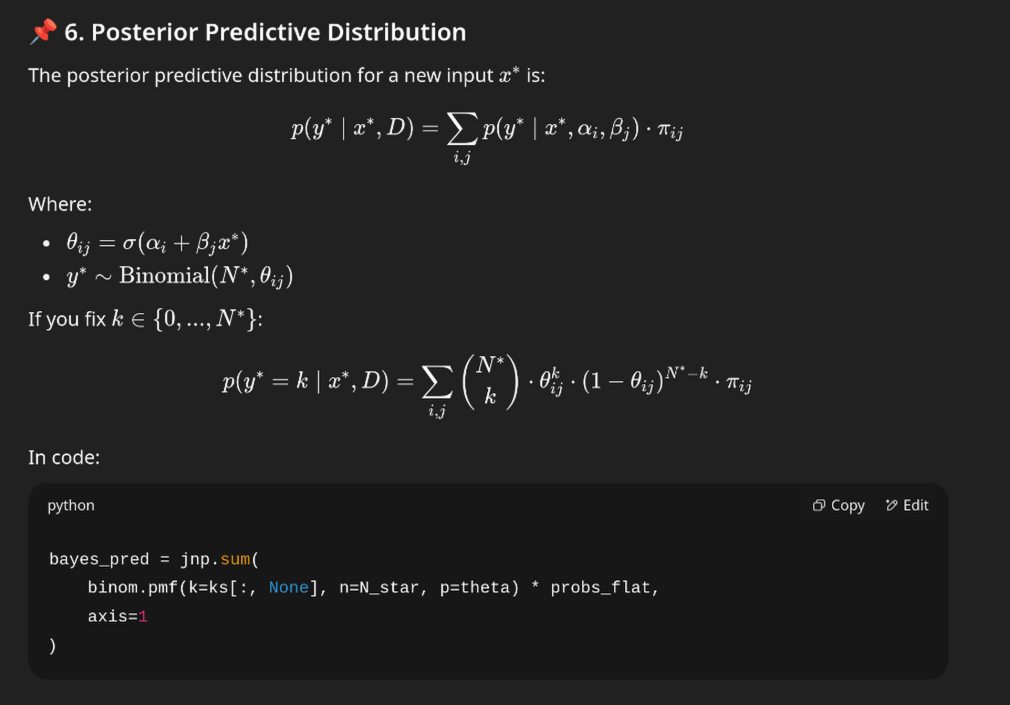

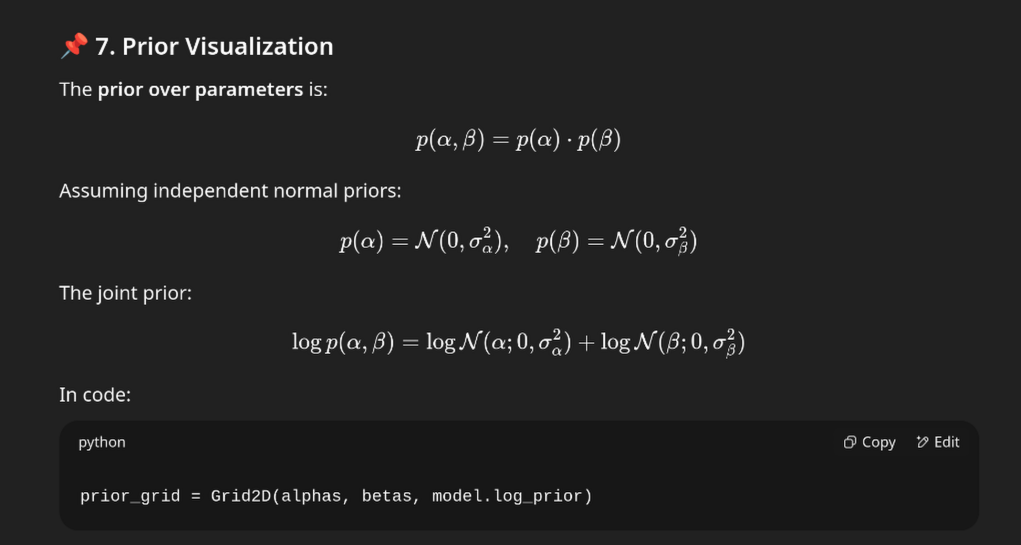

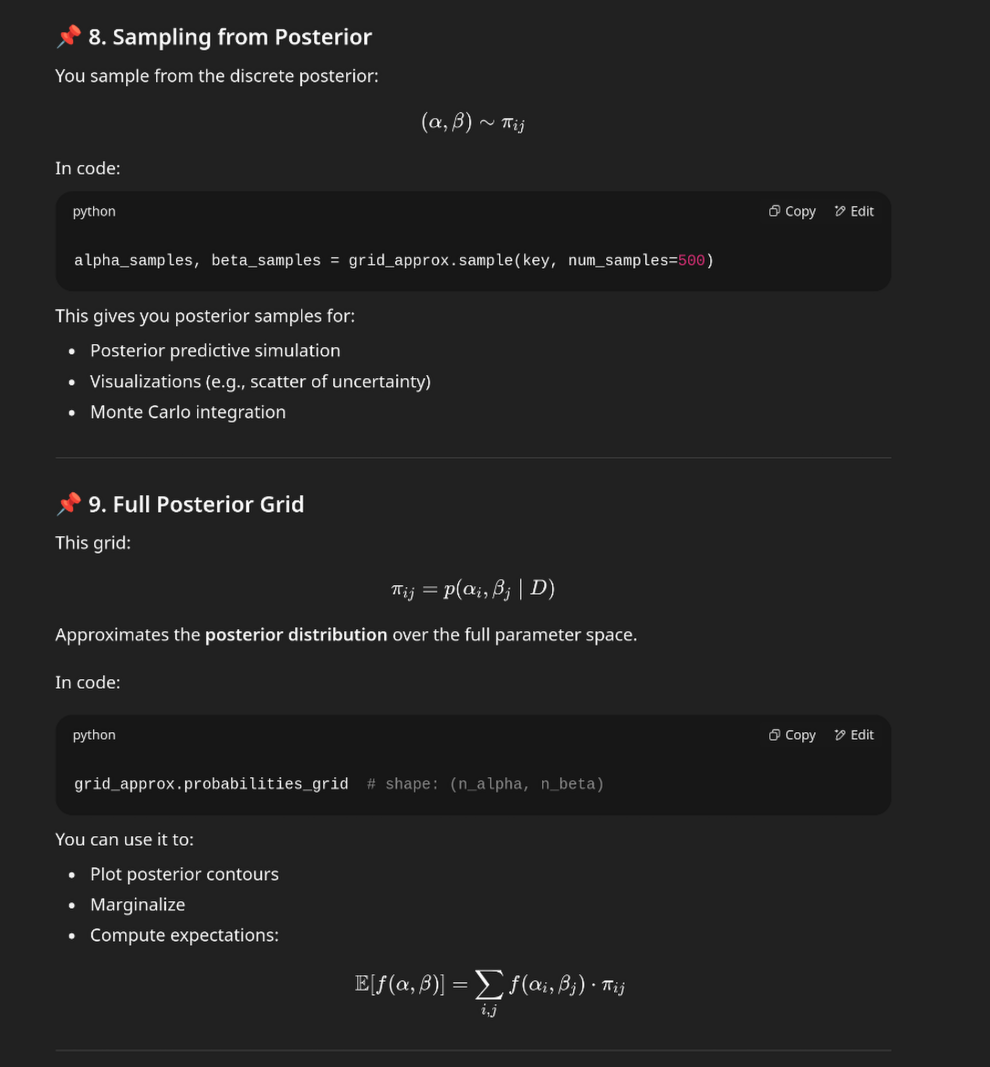